In [ ]:
# Import libraries
import tensorflow as tf
from google.colab import drive
import os
import numpy as np
import cv2
from random import shuffle
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, Input
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import time

In [ ]:
# Mount drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
# Get working directory
os.chdir("/content/drive/MyDrive/Villadolid&Larida")
cwd = os.getcwd()
print('Current Working Directory: ', cwd)

Current Working Directory:  /content/drive/MyDrive/Villadolid&Larida


In [ ]:
# Define paths
train_dir = os.path.join(cwd, 'train')

In [ ]:
# Load class names dynamically from train directory
all_classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
print('Detected Classes:', all_classes)

Detected Classes: ['dog', 'cat']


In [ ]:
# One-hot encode labels
all_labels = []
for x in range(len(all_classes)):
    label = np.zeros(len(all_classes))
    label[x] = 1
    all_labels.append(label)

In [ ]:
# Load and preprocess images
IMG_SIZE = 128
IMAGE_CHANNELS = 3
training_data = []

for label_index, specific_class in enumerate(all_classes):
    current_dir = os.path.join(train_dir, specific_class)
    print(f'Reading images from: {current_dir}')
    for img_filename in os.listdir(current_dir):
        path = os.path.join(current_dir, img_filename)
        if os.path.isfile(path):
            img = cv2.imread(path)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            training_data.append([img, all_labels[label_index]])

shuffle(training_data)

Reading images from: /content/drive/MyDrive/Villadolid&Larida/train/dog
Reading images from: /content/drive/MyDrive/Villadolid&Larida/train/cat


In [ ]:
# Split data into training and testing sets
PERCENT_TRAINING_DATA = 80
train = training_data[:int(len(training_data) * (PERCENT_TRAINING_DATA / 100))]
test = training_data[-int(len(training_data) * (PERCENT_TRAINING_DATA / 100)):]

X_train = np.array([i[0] for i in train]).reshape(-1, IMG_SIZE, IMG_SIZE, IMAGE_CHANNELS) / 255.0
Y_train = np.array([i[1] for i in train])
X_test = np.array([i[0] for i in test]).reshape(-1, IMG_SIZE, IMG_SIZE, IMAGE_CHANNELS) / 255.0
Y_test = np.array([i[1] for i in test])

print(X_train.shape, Y_train.shape)
print(X_test.shape, Y_test.shape)

(425, 128, 128, 3) (425, 2)
(425, 128, 128, 3) (425, 2)


In [ ]:
# Define model parameters
FIRST_NUM_CHANNEL = 32
FILTER_SIZE = 3
NUM_OUTPUT = len(all_classes)

In [ ]:
# Build the model
model = Sequential()
model.add(Input(shape=(IMG_SIZE, IMG_SIZE, IMAGE_CHANNELS)))
model.add(Conv2D(FIRST_NUM_CHANNEL, (FILTER_SIZE, FILTER_SIZE), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

for i in range(1, 4):
    model.add(Conv2D(FIRST_NUM_CHANNEL * (2 ** i), (FILTER_SIZE, FILTER_SIZE), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(FIRST_NUM_CHANNEL * 16, activation='relu'))
model.add(Dropout(0.8))
model.add(Dense(NUM_OUTPUT, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.0001), metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 12, 12, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       4,719,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │           1,026 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,108,546 (19.49 MB)

 Trainable params: 5,108,546 (19.49 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
NUM_EPOCHS = 50
callbacks = [EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]

start = time.time()
history = model.fit(X_train, Y_train, epochs=NUM_EPOCHS, batch_size=32, validation_data=(X_test, Y_test), callbacks=callbacks, verbose=1)
end = time.time()

print("Time elapsed in training: %.2f seconds" % (end - start))

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.4933 - loss: 0.6982 - val_accuracy: 0.5600 - val_loss: 0.6903
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.4785 - loss: 0.6936 - val_accuracy: 0.6494 - val_loss: 0.6891
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.5317 - loss: 0.6925 - val_accuracy: 0.5129 - val_loss: 0.6874
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.4787 - loss: 0.6969 - val_accuracy: 0.6871 - val_loss: 0.6863
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.5693 - loss: 0.6865 - val_accuracy: 0.6518 - val_loss: 0.6831
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.5474 - loss: 0.6830 - val_accuracy: 0.6471 - val_loss: 0.6754
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.5988 - loss: 0.6842 - val_accuracy: 0.6635 - val_loss: 0.6709
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.6341 - loss: 0.6688 - val_accuracy: 0.6471 - val_loss:

In [ ]:
# Save the model
model.save("animals-cnn.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


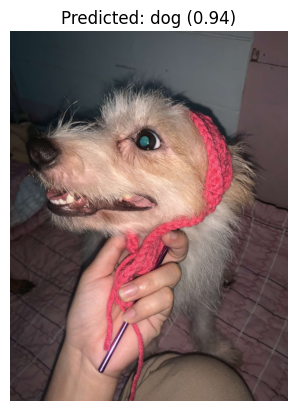

dog: 0.9426
cat: 0.0574


In [ ]:
# Test the model
TEST_IMG = os.path.join(cwd, 'dog002-test.jpg')
if os.path.exists('animals-cnn.h5'):
    model.load_weights('animals-cnn.h5')
    test_img = cv2.imread(TEST_IMG)

    if test_img is not None:
        test_img_resized = cv2.resize(test_img, (IMG_SIZE, IMG_SIZE))
        data = test_img_resized.astype('float32') / 255.0
        data = np.expand_dims(data, axis=0)

        predictions = model.predict(data)[0]
        predicted_index = np.argmax(predictions)
        predicted_label = all_classes[predicted_index]
        confidence = predictions[predicted_index]

        plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
        plt.title(f'Predicted: {predicted_label} ({confidence:.2f})')
        plt.axis('off')
        plt.show()

        for i, class_name in enumerate(all_classes):
            print(f'{class_name}: {predictions[i]:.4f}')
    else:
        print(f"Error: Could not load image from {TEST_IMG}. Check the file path.")